In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv("../data/bankloan.csv")

(df['Experience'] < 0).sum()


np.int64(52)

In [2]:
df[df['Experience'] < 0]

,ID,Age,Experience,Income,ZIP.Code,Family,CCAvg,Education,Mortgage,Personal.Loan,Securities.Account,CD.Account,Online,CreditCard
89,90,25,-1,113,94303,4,2.30,3,0,0,0,0,0,1
226,227,24,-1,39,94085,2,1.70,2,0,0,0,0,0,0
315,316,24,-2,51,90630,3,0.30,3,0,0,0,0,1,0
451,452,28,-2,48,94132,2,1.75,3,89,0,0,0,1,0
524,525,24,-1,75,93014,4,0.20,1,0,0,0,0,1,0
536,537,25,-1,43,92173,3,2.40,2,176,0,0,0,1,0
540,541,25,-1,109,94010,4,2.30,3,314,0,0,0,1,0
576,577,25,-1,48,92870,3,0.30,3,0,0,0,0,0,1
583,584,24,-1,38,95045,2,1.70,2,0,0,0,0,1,0
597,598,24,-2,125,92835,2,7.20,1,0,0,1,0,0,1


In [3]:
df['Experience'] = df['Experience'].abs()
(df['Experience'] < 0).sum()

np.int64(0)

In [4]:
df.drop(['ID', 'ZIP.Code'], axis=1, inplace=True)

In [5]:
df.head()

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal.Loan,Securities.Account,CD.Account,Online,CreditCard
0,25,1,49,4,1.6,1,0,0,1,0,0,0
1,45,19,34,3,1.5,1,0,0,1,0,0,0
2,39,15,11,1,1.0,1,0,0,0,0,0,0
3,35,9,100,1,2.7,2,0,0,0,0,0,0
4,35,8,45,4,1.0,2,0,0,0,0,0,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 5000 non-null   int64  
 1   Experience          5000 non-null   int64  
 2   Income              5000 non-null   int64  
 3   Family              5000 non-null   int64  
 4   CCAvg               5000 non-null   float64
 5   Education           5000 non-null   int64  
 6   Mortgage            5000 non-null   int64  
 7   Personal.Loan       5000 non-null   int64  
 8   Securities.Account  5000 non-null   int64  
 9   CD.Account          5000 non-null   int64  
 10  Online              5000 non-null   int64  
 11  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 468.9 KB


In [7]:
df.shape

(5000, 12)

## Data Cleaning – Observations

    No missing values were found in the dataset.
    No duplicate records were found.
    52 negative values were found in the Experience column.
    Negative Experience values were converted to positive values using the absolute value.
    ID was removed because it is only a unique identifier.
    ZIP.Code was removed because it is not useful for predicting personal loan acceptance.
    The cleaned dataset now contains 5,000 rows and 12 columns and is ready for Exploratory Data Analysis (EDA).

# Step 3 EDA 

<Axes: xlabel='Personal.Loan'>

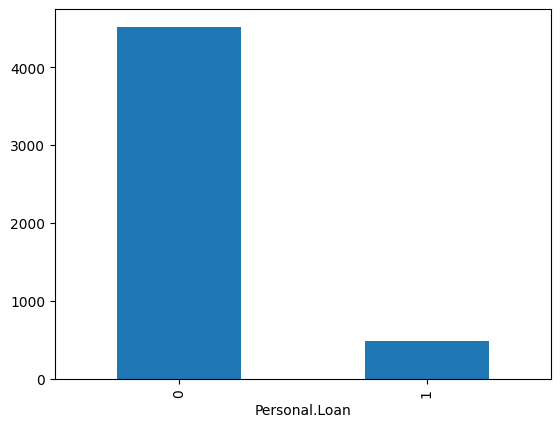

In [8]:
df['Personal.Loan'].value_counts().plot(kind='bar')

<Axes: >

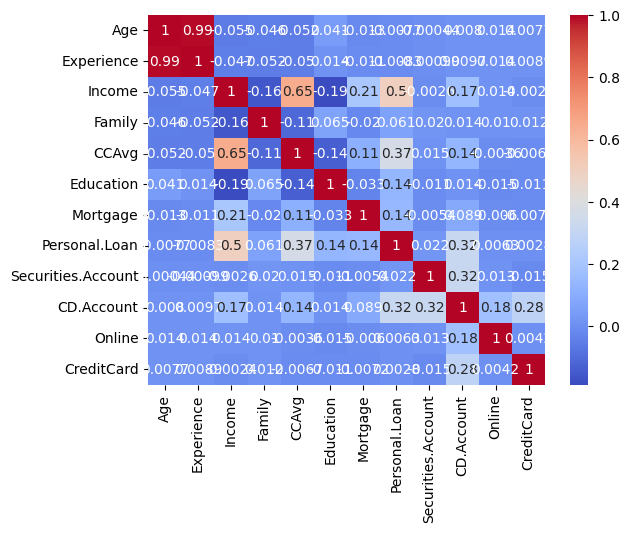

In [9]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

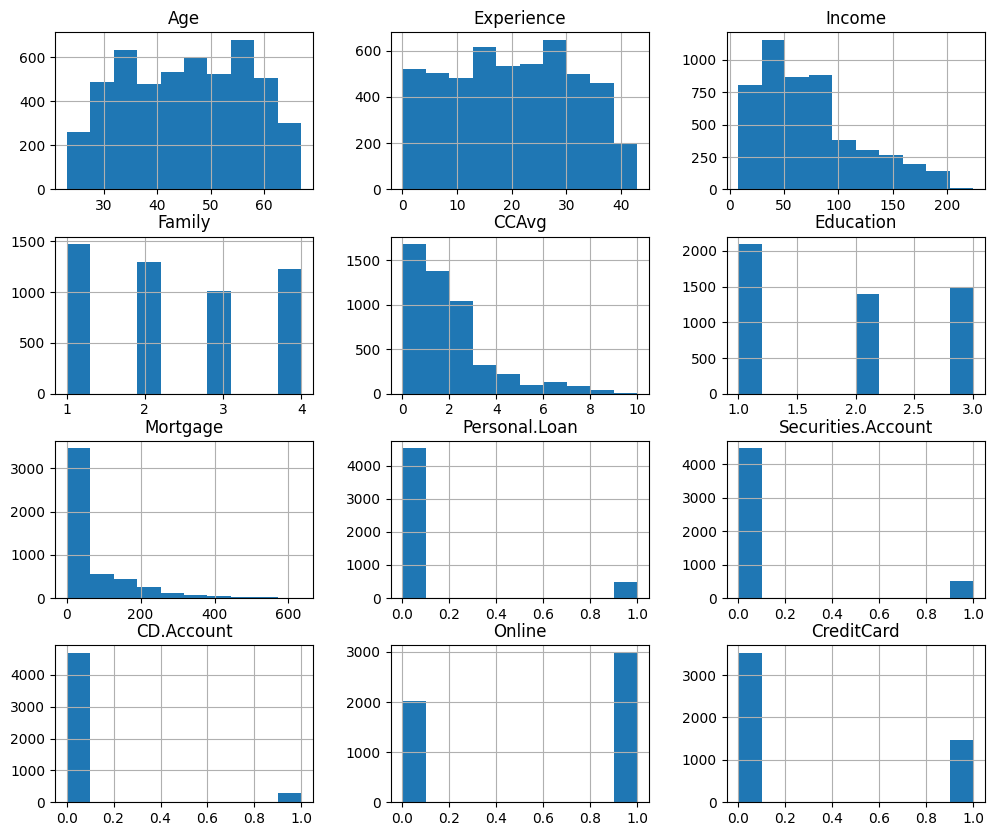

In [10]:
df.hist(figsize=(12,10))
plt.show()

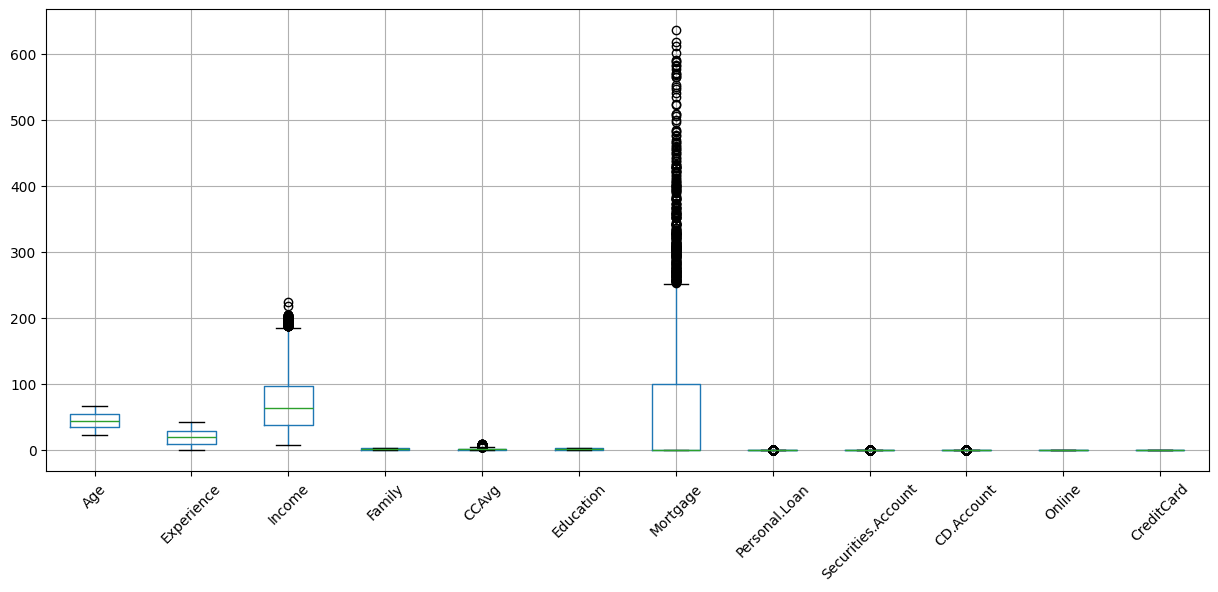

In [11]:
df.boxplot(figsize=(15,6))
plt.xticks(rotation=45)
plt.show()

In [12]:
df.to_csv("cleaned_personal_loan.csv", index=False)

## EDA Observations

    The target variable (Personal.Loan) is imbalanced, with far more customers not accepting a loan than accepting one.

    Income, CCAvg, and Mortgage are right-skewed and contain some high-value observations (outliers).
    Age and Experience appear to have similar distributions indicating a strong relationship between the two features.

    Most customers do not have a Securities Account or CD Account.
    More customers use Online Banking, while fewer customers own a Credit Card.

    The dataset contains features with different value ranges, therefore feature scaling is required before training the neural network.